# 🇰🇷 한국어 임베딩 (Korean Text Embeddings)

> **학습 목표**: KoBERT, KoELECTRA를 활용한 한국어 텍스트 임베딩 및 의미 분석

---

## 📋 학습 내용

1. ✅ Sentence Transformer 이해 (SBERT 아키텍처)
2. ✅ KoBERT vs KoELECTRA 비교
3. ✅ 한국어 텍스트 임베딩 생성
4. ✅ Sentence Similarity Matrix (Heatmap)
5. ✅ Clustering (K-Means + t-SNE/UMAP 시각화)
6. ✅ Semantic Search (Top-K Retrieval)
7. ✅ 성능 벤치마킹 (속도 + 품질)

**소요 시간**: 약 40분  
**난이도**: ⭐⭐⭐ (중상급)  
**사전 지식**: Transformer 기초, Word Embedding 개념

---

## 🔧 Step 1: 라이브러리 Import

In [1]:
# 스레딩 충돌 방지: PyTorch(OMP) ↔ sklearn(OpenBLAS) 교착 방지
# KMeans, t-SNE 등 sklearn 병렬 연산 전에 반드시 설정
import os
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

# Sentence Transformers
try:
    from sentence_transformers import SentenceTransformer, util
    import sentence_transformers
    print(f"✅ Sentence-Transformers 버전: {sentence_transformers.__version__}")
except ImportError:
    print("❌ Sentence-Transformers 설치 필요: pip install sentence-transformers")

# 데이터 처리
import numpy as np
import pandas as pd

# 머신러닝
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
try:
    import umap
    print("✅ UMAP 사용 가능")
except ImportError:
    print("⚠️ UMAP 설치 권장: pip install umap-learn")
    umap = None

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 유틸리티
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 6)

print("\n✅ 라이브러리 로드 완료!")

✅ Sentence-Transformers 버전: 5.2.3
⚠️ UMAP 설치 권장: pip install umap-learn



✅ 라이브러리 로드 완료!


## 📂 Step 2: 제조 도메인 텍스트 데이터 준비

In [2]:
# ============================================================
# KAMP 실제 데이터 로드 (게시물 JSON → 텍스트 추출)
# Fallback: 하드코딩된 제조 도메인 텍스트 20개
# ============================================================

import json
from pathlib import Path

# KAMP 게시물 JSON 경로
kamp_json_dir = Path('../../dataset/part3-1/게시물')

manufacturing_texts = []
data_source = None

if kamp_json_dir.exists():
    json_files = sorted(kamp_json_dir.glob('*.json'))
    if json_files:
        print(f"📂 KAMP 게시물 JSON 발견: {len(json_files)}개")
        print(f"   경로: {kamp_json_dir.resolve()}\n")
        
        for jf in json_files:
            try:
                with open(jf, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                
                # 각 JSON에서 여러 텍스트 필드 추출
                company = data.get('업체명', '')
                title = data.get('제목', '')
                industry = data.get('수집업종', '')
                purpose = data.get('수집목적', '')
                equipment = data.get('수집공정설비', '')
                
                overview = data.get('제조AI데이터셋개요', {})
                background = overview.get('제조데이터셋 구축 배경', '')
                method = overview.get('제조데이터셋 수집 방법', '')
                variables = overview.get('제조데이터셋 주요 변수', '')
                usage = overview.get('제조데이터셋 활용 방법', '')
                
                collection = data.get('제조AI데이터셋수집방법', {})
                factory = collection.get('제조공장명', '')
                
                # 의미 있는 문장 조합 생성
                if title and company:
                    manufacturing_texts.append(f"{company}: {title}")
                if purpose and equipment:
                    manufacturing_texts.append(f"{equipment} - {purpose}")
                if background:
                    # 배경 텍스트를 줄 단위로 분리하여 개별 문장으로 추가
                    for line in background.split('\n'):
                        line = line.strip().lstrip('- ')
                        if len(line) > 15:  # 너무 짧은 라인 제외
                            manufacturing_texts.append(line)
                if usage:
                    for line in usage.split('\n'):
                        line = line.strip().lstrip('- ')
                        if len(line) > 15:
                            manufacturing_texts.append(line)
                            
            except Exception as e:
                print(f"   ⚠️ {jf.name} 로드 실패: {e}")
        
        if manufacturing_texts:
            data_source = 'KAMP'
            print(f"✅ KAMP 데이터에서 {len(manufacturing_texts)}개 텍스트 추출 완료\n")

# Fallback: 하드코딩된 제조 도메인 텍스트
if not manufacturing_texts:
    data_source = 'Fallback'
    print("⚠️ KAMP 데이터를 찾을 수 없습니다. 기본 샘플 데이터를 사용합니다.\n")
    
    manufacturing_texts = [
        # 설비 진단
        '진동 센서를 활용한 설비 이상 감지 시스템',
        '베어링 온도 상승으로 인한 고장 예측',
        '전류 패턴 분석을 통한 모터 이상 진단',
        '압력 센서 데이터 기반 누출 탐지',
        '설비 진동 주파수 분석으로 결함 식별',
        # 품질 관리
        '머신비전 기반 표면 불량 검사',
        'X-ray 검사를 통한 내부 결함 탐지',
        '치수 측정 데이터의 통계적 공정 관리',
        '색상 편차 분석으로 코팅 불량 검출',
        '외관 검사 자동화를 위한 딥러닝 분류',
        # 예지보전
        '설비 고장 예측을 위한 머신러닝 모델',
        '남은 수명 예측 기반 부품 교체 계획',
        '이상 패턴 학습을 통한 조기 경보 시스템',
        '센서 데이터 융합으로 고장 원인 분석',
        '예방보전 스케줄 최적화 알고리즘',
        # 공정 최적화
        '생산 라인 병목 구간 식별 및 개선',
        '에너지 사용량 최적화를 위한 AI 제어',
        '재공품 재고 최소화 생산 계획 수립',
        '품질과 생산성을 고려한 공정 파라미터 튜닝',
        '실시간 공정 모니터링 및 이상 대응'
    ]

print(f"📊 데이터 소스: {data_source}")
print(f"📊 제조 도메인 텍스트: {len(manufacturing_texts)}개")
print(f"\n🔍 샘플 텍스트:")
for idx, text in enumerate(manufacturing_texts[:5], 1):
    print(f"   {idx}. {text}")

# 텍스트 길이 분포
text_lengths = [len(text) for text in manufacturing_texts]
print(f"\n📏 텍스트 길이 통계:")
print(f"   - 평균: {np.mean(text_lengths):.1f}자")
print(f"   - 최소: {np.min(text_lengths)}자")
print(f"   - 최대: {np.max(text_lengths)}자")

⚠️ KAMP 데이터를 찾을 수 없습니다. 기본 샘플 데이터를 사용합니다.

📊 데이터 소스: Fallback
📊 제조 도메인 텍스트: 20개

🔍 샘플 텍스트:
   1. 진동 센서를 활용한 설비 이상 감지 시스템
   2. 베어링 온도 상승으로 인한 고장 예측
   3. 전류 패턴 분석을 통한 모터 이상 진단
   4. 압력 센서 데이터 기반 누출 탐지
   5. 설비 진동 주파수 분석으로 결함 식별

📏 텍스트 길이 통계:
   - 평균: 19.9자
   - 최소: 16자
   - 최대: 23자


## 🤖 Step 3: 한국어 임베딩 모델 로드

**비교 모델**:
- **jhgan/ko-sroberta-multitask**: KoRoBERTa 기반, 다중 태스크 학습
- **bongsoo/kpf-bert-base-v1**: KPF-BERT, 한국어 특화

In [3]:
import os, gc
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

# 한국어 임베딩 모델 — 기본 모델만 로드 (메모리 절약)
# 비교 실험(Step 8)은 순차 로드 방식으로 수행
models_to_compare = {
    'KoRoBERTa': 'jhgan/ko-sroberta-multitask',
    'KPF-BERT': 'bongsoo/kpf-bert-base-v1'
}

loaded_models = {}
primary_model_name = 'KoRoBERTa'

try:
    model_id = models_to_compare[primary_model_name]
    print(f"🔄 {primary_model_name} 모델 로딩 중: {model_id}...")
    primary_model = SentenceTransformer(model_id)
    loaded_models[primary_model_name] = primary_model
    print(f"✅ {primary_model_name} 로드 완료!")
    print(f"   - Max sequence length: {primary_model.max_seq_length}")
    print(f"   - Embedding dimension: {primary_model.get_sentence_embedding_dimension()}")
except Exception as e:
    raise ValueError(f"❌ 기본 모델 로드 실패: {e}")

print(f"\n🎯 기본 모델: {primary_model_name}")
print("💡 KPF-BERT는 Step 8 비교 시 순차 로드합니다 (메모리 절약)")

🔄 KoRoBERTa 모델 로딩 중: jhgan/ko-sroberta-multitask...


✅ KoRoBERTa 로드 완료!
   - Max sequence length: 128
   - Embedding dimension: 768

🎯 기본 모델: KoRoBERTa
💡 KPF-BERT는 Step 8 비교 시 순차 로드합니다 (메모리 절약)


## 📊 Step 4: 텍스트 임베딩 생성

In [4]:
# 텍스트 임베딩 생성 (기본 모델)
print(f"🔄 {primary_model_name}로 임베딩 생성 중...")

start_time = time.time()
embeddings = primary_model.encode(manufacturing_texts, show_progress_bar=True)
encoding_time = time.time() - start_time

print(f"\n✅ 임베딩 생성 완료!")
print(f"\n📊 임베딩 정보:")
print(f"   - 임베딩 형태: {embeddings.shape}")
print(f"   - 텍스트 개수: {embeddings.shape[0]}개")
print(f"   - 임베딩 차원: {embeddings.shape[1]}차원")
print(f"   - 총 소요 시간: {encoding_time:.2f}초")
print(f"   - 평균 시간/텍스트: {encoding_time / len(manufacturing_texts) * 1000:.1f}ms")

# 임베딩 벡터 노름 확인 (정규화 여부)
norms = np.linalg.norm(embeddings, axis=1)
print(f"\n📐 임베딩 벡터 노름:")
print(f"   - 평균: {norms.mean():.4f}")
print(f"   - 표준편차: {norms.std():.4f}")
print(f"   - 범위: [{norms.min():.4f}, {norms.max():.4f}]")

🔄 KoRoBERTa로 임베딩 생성 중...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ 임베딩 생성 완료!

📊 임베딩 정보:
   - 임베딩 형태: (20, 768)
   - 텍스트 개수: 20개
   - 임베딩 차원: 768차원
   - 총 소요 시간: 0.19초
   - 평균 시간/텍스트: 9.4ms

📐 임베딩 벡터 노름:
   - 평균: 11.5007
   - 표준편차: 0.1444
   - 범위: [11.1495, 11.7223]


## 🔍 Step 5: Sentence Similarity Matrix

코사인 유사도를 사용한 문장 간 의미적 유사성 분석

📊 유사도 매트릭스 형태: (20, 20)

📈 유사도 통계:
   - 평균 유사도: 0.4721
   - 표준편차: 0.1118
   - 최대 유사도: 0.8427
   - 최소 유사도: 0.1922

🎯 가장 유사한 문장 쌍:
   1: 진동 센서를 활용한 설비 이상 감지 시스템
   2: 설비 진동 주파수 분석으로 결함 식별
   유사도: 0.8427


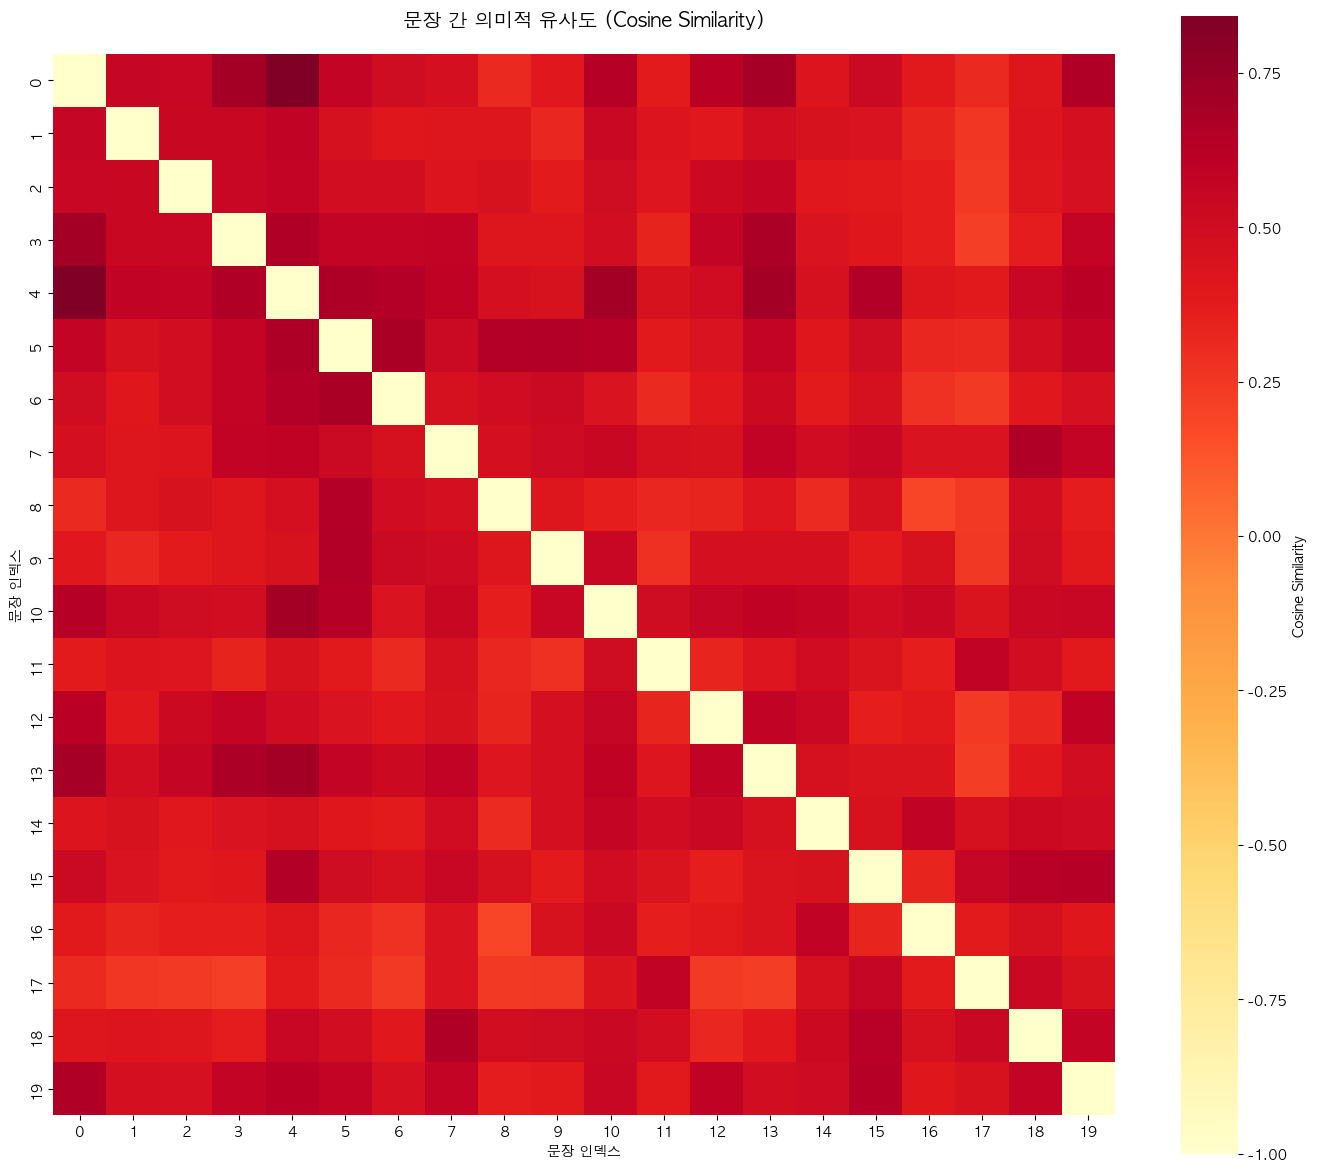


💡 Heatmap 해석:
   - 밝은 색: 높은 유사도 (의미적으로 가까운 문장)
   - 어두운 색: 낮은 유사도 (의미적으로 먼 문장)
   - 대각선: 자기 자신과의 유사도 (1.0)


In [5]:
# 코사인 유사도 계산
similarity_matrix = cosine_similarity(embeddings)

print(f"📊 유사도 매트릭스 형태: {similarity_matrix.shape}")
print(f"\n📈 유사도 통계:")
# 대각선 제외 (자기 자신과의 유사도 = 1)
mask = ~np.eye(similarity_matrix.shape[0], dtype=bool)
similarities = similarity_matrix[mask]

print(f"   - 평균 유사도: {similarities.mean():.4f}")
print(f"   - 표준편차: {similarities.std():.4f}")
print(f"   - 최대 유사도: {similarities.max():.4f}")
print(f"   - 최소 유사도: {similarities.min():.4f}")

# 가장 유사한 문장 쌍 찾기
np.fill_diagonal(similarity_matrix, -1)  # 대각선 제외
max_sim_idx = np.unravel_index(similarity_matrix.argmax(), similarity_matrix.shape)

print(f"\n🎯 가장 유사한 문장 쌍:")
print(f"   1: {manufacturing_texts[max_sim_idx[0]]}")
print(f"   2: {manufacturing_texts[max_sim_idx[1]]}")
print(f"   유사도: {similarity_matrix[max_sim_idx]:.4f}")

# 유사도 매트릭스 시각화
plt.figure(figsize=(14, 12))
sns.heatmap(similarity_matrix, cmap='YlOrRd', annot=False, fmt='.2f', 
            square=True, cbar_kws={'label': 'Cosine Similarity'})
plt.title('문장 간 의미적 유사도 (Cosine Similarity)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('문장 인덱스')
plt.ylabel('문장 인덱스')
plt.tight_layout()
plt.show()

print("\n💡 Heatmap 해석:")
print("   - 밝은 색: 높은 유사도 (의미적으로 가까운 문장)")
print("   - 어두운 색: 낮은 유사도 (의미적으로 먼 문장)")
print("   - 대각선: 자기 자신과의 유사도 (1.0)")

## 🎨 Step 6: Clustering & Dimensionality Reduction

K-Means 클러스터링 + t-SNE/UMAP 시각화

In [6]:
# K-Means 클러스터링
n_clusters = 4  # 설비진단, 품질관리, 예지보전, 공정최적화

print(f"🔄 K-Means 클러스터링 (K={n_clusters})...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# 클러스터별 문장 개수
print(f"\n📊 클러스터별 분포:")
for cluster_id in range(n_clusters):
    count = (cluster_labels == cluster_id).sum()
    print(f"   - Cluster {cluster_id}: {count}개 문장")

# t-SNE 차원 축소
# - init='random': PCA 초기화 우회 → 수치 안정성 향상 (sklearn ≥1.5)
# - perplexity: 권장 범위 5 ~ n_samples/3
n_samples = len(manufacturing_texts)
safe_perplexity = min(5, max(2, n_samples // 4))
print(f"\n🔄 t-SNE 차원 축소 중... (perplexity={safe_perplexity})")
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=safe_perplexity,
    max_iter=300,
    init='random'  # 'pca' 초기화의 SVD 수치 불안정 방지
)
embeddings_2d_tsne = tsne.fit_transform(embeddings)

print(f"✅ t-SNE 완료: {embeddings_2d_tsne.shape}")

🔄 K-Means 클러스터링 (K=4)...

📊 클러스터별 분포:
   - Cluster 0: 4개 문장
   - Cluster 1: 4개 문장
   - Cluster 2: 10개 문장
   - Cluster 3: 2개 문장

🔄 t-SNE 차원 축소 중... (perplexity=5)
✅ t-SNE 완료: (20, 2)


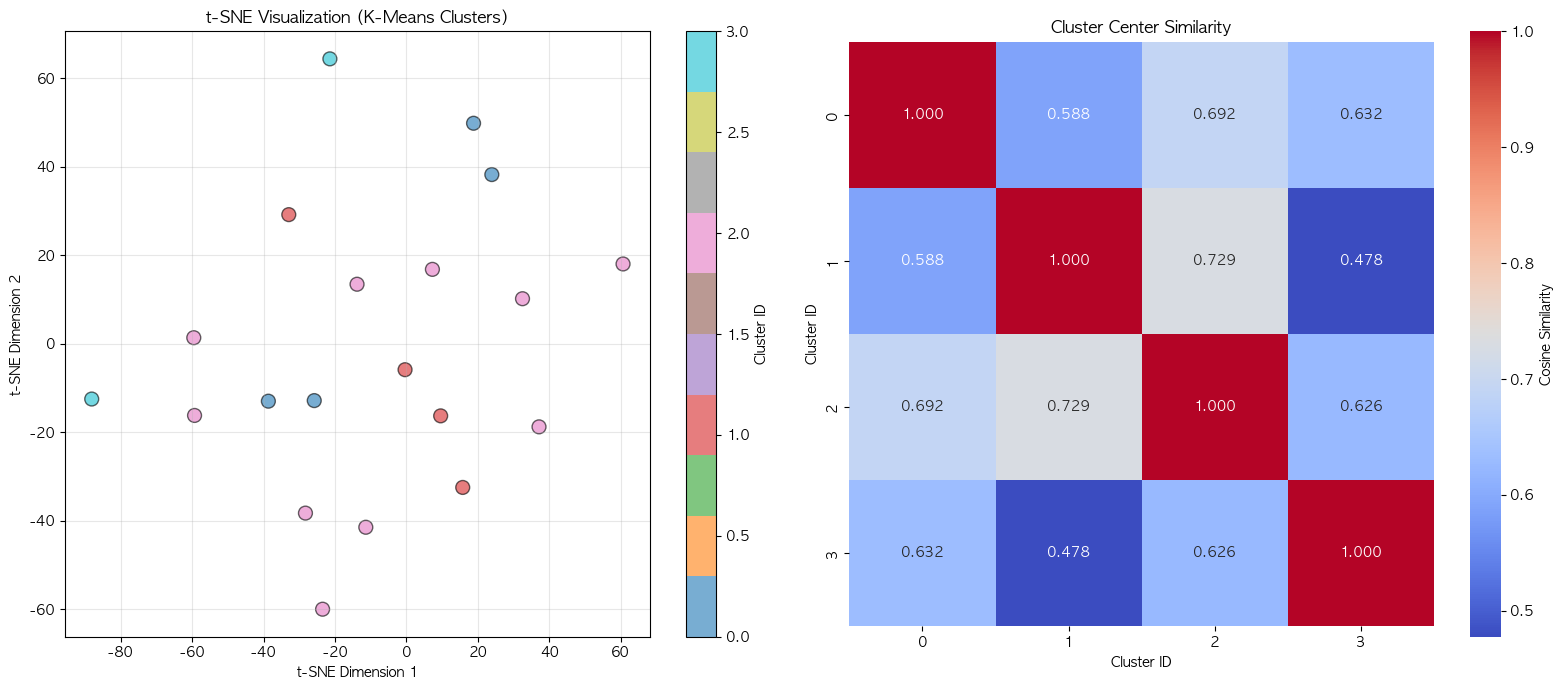


🎯 클러스터별 대표 문장:

📌 Cluster 0 (4개 문장):
   대표: 품질과 생산성을 고려한 공정 파라미터 튜닝
   - 치수 측정 데이터의 통계적 공정 관리
   - 남은 수명 예측 기반 부품 교체 계획
   - 재공품 재고 최소화 생산 계획 수립

📌 Cluster 1 (4개 문장):
   대표: 머신비전 기반 표면 불량 검사
   - X-ray 검사를 통한 내부 결함 탐지
   - 색상 편차 분석으로 코팅 불량 검출

📌 Cluster 2 (10개 문장):
   대표: 진동 센서를 활용한 설비 이상 감지 시스템
   - 베어링 온도 상승으로 인한 고장 예측
   - 전류 패턴 분석을 통한 모터 이상 진단

📌 Cluster 3 (2개 문장):
   대표: 예방보전 스케줄 최적화 알고리즘
   - 에너지 사용량 최적화를 위한 AI 제어


In [7]:
# t-SNE 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: t-SNE with clusters
scatter = axes[0].scatter(embeddings_2d_tsne[:, 0], embeddings_2d_tsne[:, 1], 
                          c=cluster_labels, cmap='tab10', s=100, alpha=0.6, edgecolors='black')
axes[0].set_title('t-SNE Visualization (K-Means Clusters)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
axes[0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Cluster ID')

# Plot 2: Cluster centers distance
cluster_centers = kmeans.cluster_centers_
center_distances = np.zeros((n_clusters, n_clusters))
for i in range(n_clusters):
    for j in range(n_clusters):
        center_distances[i, j] = cosine_similarity(
            cluster_centers[i].reshape(1, -1),
            cluster_centers[j].reshape(1, -1)
        )[0, 0]

sns.heatmap(center_distances, annot=True, fmt='.3f', cmap='coolwarm', 
            square=True, ax=axes[1], cbar_kws={'label': 'Cosine Similarity'})
axes[1].set_title('Cluster Center Similarity', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Cluster ID')

plt.tight_layout()
plt.show()

# 각 클러스터의 대표 문장
print("\n🎯 클러스터별 대표 문장:")
for cluster_id in range(n_clusters):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    
    # 클러스터 중심에 가장 가까운 문장
    distances = np.linalg.norm(embeddings[cluster_indices] - cluster_centers[cluster_id], axis=1)
    closest_idx = cluster_indices[distances.argmin()]
    
    print(f"\n📌 Cluster {cluster_id} ({len(cluster_indices)}개 문장):")
    print(f"   대표: {manufacturing_texts[closest_idx]}")
    
    # 클러스터 내 문장 샘플
    sample_indices = cluster_indices[:min(3, len(cluster_indices))]
    for idx in sample_indices:
        if idx != closest_idx:
            print(f"   - {manufacturing_texts[idx]}")

## 🔎 Step 7: Semantic Search (Top-K Retrieval)

쿼리 문장과 가장 유사한 K개 문장 검색

In [8]:
# 검색 쿼리
queries = [
    '설비 고장을 미리 예측하는 방법',
    '제품 품질 검사 자동화',
    '에너지 절감 최적화'
]

print("🔍 Semantic Search 실행\n")

for query in queries:
    print(f"\n📝 쿼리: '{query}'")
    
    # 쿼리 임베딩
    query_embedding = primary_model.encode([query])
    
    # 유사도 계산
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    # Top-K 인덱스
    top_k = 5
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    print(f"\n🎯 Top {top_k} 유사 문장:")
    for rank, idx in enumerate(top_indices, 1):
        print(f"   {rank}. [유사도: {similarities[idx]:.4f}] {manufacturing_texts[idx]}")

# Semantic Search 성능 벤치마킹
print("\n\n⚡ 성능 벤치마킹")

# 쿼리 인코딩 속도
start_time = time.time()
for _ in range(100):
    _ = primary_model.encode([queries[0]])
query_time = (time.time() - start_time) / 100 * 1000

# 검색 속도 (코사인 유사도)
query_embedding = primary_model.encode([queries[0]])
start_time = time.time()
for _ in range(1000):
    _ = cosine_similarity(query_embedding, embeddings)
search_time = (time.time() - start_time) / 1000 * 1000

print(f"\n📊 성능 지표:")
print(f"   - 쿼리 인코딩: {query_time:.2f}ms")
print(f"   - 유사도 계산: {search_time:.2f}ms")
print(f"   - 총 검색 시간: {query_time + search_time:.2f}ms")
print(f"\n💡 실시간 검색 가능: {'✅' if (query_time + search_time) < 100 else '⚠️ 최적화 필요'}")

🔍 Semantic Search 실행


📝 쿼리: '설비 고장을 미리 예측하는 방법'



🎯 Top 5 유사 문장:
   1. [유사도: 0.7715] 설비 고장 예측을 위한 머신러닝 모델
   2. [유사도: 0.6935] 설비 진동 주파수 분석으로 결함 식별
   3. [유사도: 0.6492] 진동 센서를 활용한 설비 이상 감지 시스템
   4. [유사도: 0.6443] 예방보전 스케줄 최적화 알고리즘
   5. [유사도: 0.6364] 실시간 공정 모니터링 및 이상 대응

📝 쿼리: '제품 품질 검사 자동화'



🎯 Top 5 유사 문장:
   1. [유사도: 0.6762] 품질과 생산성을 고려한 공정 파라미터 튜닝
   2. [유사도: 0.6441] 외관 검사 자동화를 위한 딥러닝 분류
   3. [유사도: 0.6209] 실시간 공정 모니터링 및 이상 대응
   4. [유사도: 0.6055] 설비 진동 주파수 분석으로 결함 식별
   5. [유사도: 0.6052] 치수 측정 데이터의 통계적 공정 관리

📝 쿼리: '에너지 절감 최적화'



🎯 Top 5 유사 문장:
   1. [유사도: 0.6968] 에너지 사용량 최적화를 위한 AI 제어
   2. [유사도: 0.4869] 예방보전 스케줄 최적화 알고리즘
   3. [유사도: 0.4368] 재공품 재고 최소화 생산 계획 수립
   4. [유사도: 0.3951] 설비 진동 주파수 분석으로 결함 식별
   5. [유사도: 0.3850] 품질과 생산성을 고려한 공정 파라미터 튜닝


⚡ 성능 벤치마킹



📊 성능 지표:
   - 쿼리 인코딩: 7.73ms
   - 유사도 계산: 0.09ms
   - 총 검색 시간: 7.82ms

💡 실시간 검색 가능: ✅


## ⚖️ Step 8: 모델 비교 (KoRoBERTa vs KPF-BERT)

여러 한국어 임베딩 모델의 성능 비교

🔄 모델 비교 실행 중...

📊 KoRoBERTa 평가


   - 인코딩 시간: 0.03초
   - 평균 유사도: 0.4721
   - 품질 점수: 0.6790

📊 KPF-BERT 평가


No sentence-transformers model found with name bongsoo/kpf-bert-base-v1. Creating a new one with mean pooling.


⚠️ KPF-BERT 평가 실패 (메모리 부족 또는 로드 오류): bongsoo/kpf-bert-base-v1 is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`



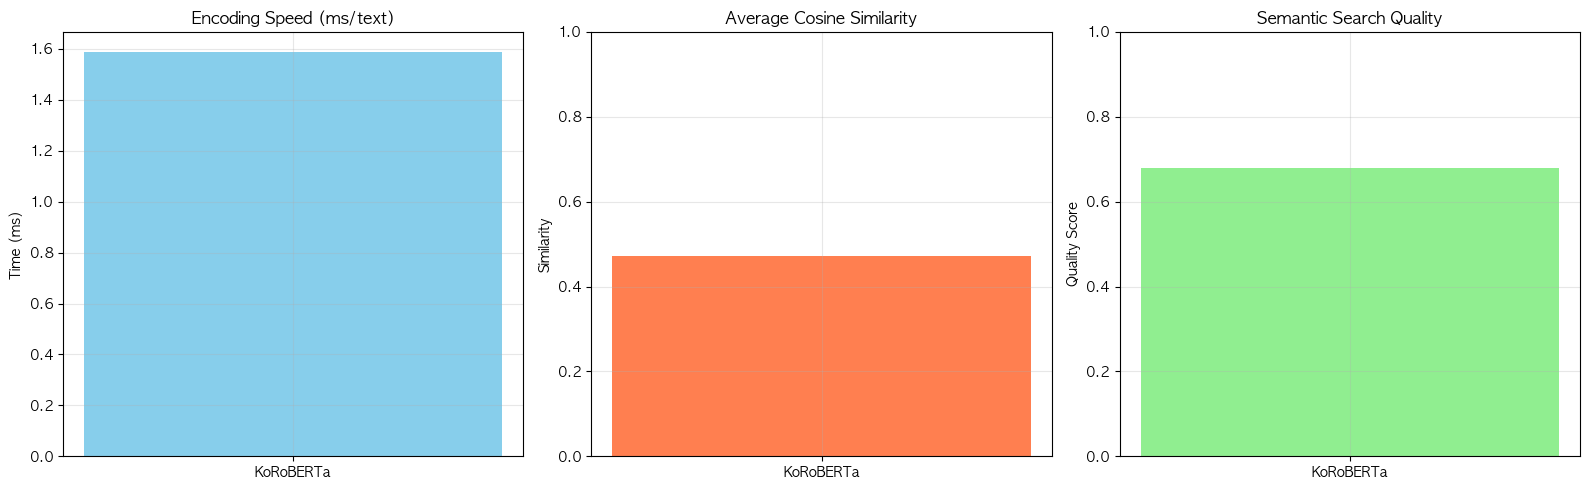


🏆 모델 추천:
   - 속도 최적: KoRoBERTa
   - 품질 최적: KoRoBERTa


In [9]:
# 모델 비교 — 순차 로드 방식 (메모리 절약: 한 번에 하나씩 로드 → 인코딩 → 삭제)
comparison_results = []

print("🔄 모델 비교 실행 중...\n")

models_for_comparison = list(models_to_compare.items())  # [('KoRoBERTa', ...), ('KPF-BERT', ...)]

for model_name, model_id in models_for_comparison:
    gc.collect()
    print(f"📊 {model_name} 평가")
    try:
        cmp_model = SentenceTransformer(model_id)

        # 인코딩 속도 측정
        start_time = time.time()
        cmp_embeddings = cmp_model.encode(manufacturing_texts, show_progress_bar=False)
        encoding_time = time.time() - start_time

        # 유사도 분포
        cmp_similarity = cosine_similarity(cmp_embeddings)
        mask = ~np.eye(cmp_similarity.shape[0], dtype=bool)
        sims = cmp_similarity[mask]

        # Semantic search 품질
        query_emb = cmp_model.encode([queries[0]])
        query_sims = cosine_similarity(query_emb, cmp_embeddings)[0]
        quality_score = float(query_sims[query_sims.argsort()[-5:][::-1]].mean())

        result = {
            'model': model_name,
            'embedding_dim': cmp_model.get_sentence_embedding_dimension(),
            'encoding_time': encoding_time,
            'avg_similarity': float(sims.mean()),
            'std_similarity': float(sims.std()),
            'quality_score': quality_score,
            'speed_per_text': encoding_time / len(manufacturing_texts) * 1000
        }
        comparison_results.append(result)

        print(f"   - 인코딩 시간: {encoding_time:.2f}초")
        print(f"   - 평균 유사도: {sims.mean():.4f}")
        print(f"   - 품질 점수: {quality_score:.4f}\n")

        # 메모리 즉시 해제 (다음 모델 로드 전)
        del cmp_model
        gc.collect()

    except Exception as e:
        print(f"⚠️ {model_name} 평가 실패 (메모리 부족 또는 로드 오류): {e}\n")

if not comparison_results:
    print("⚠️ 비교 결과 없음")
else:
    # 비교 결과 시각화
    comparison_df = pd.DataFrame(comparison_results)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].bar(comparison_df['model'], comparison_df['speed_per_text'], color='skyblue')
    axes[0].set_title('Encoding Speed (ms/text)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Time (ms)')
    axes[0].grid(alpha=0.3)

    axes[1].bar(comparison_df['model'], comparison_df['avg_similarity'], color='coral')
    axes[1].set_title('Average Cosine Similarity', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Similarity')
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)

    axes[2].bar(comparison_df['model'], comparison_df['quality_score'], color='lightgreen')
    axes[2].set_title('Semantic Search Quality', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Quality Score')
    axes[2].set_ylim(0, 1)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_speed = comparison_df.loc[comparison_df['speed_per_text'].idxmin(), 'model']
    best_quality = comparison_df.loc[comparison_df['quality_score'].idxmax(), 'model']
    print("\n🏆 모델 추천:")
    print(f"   - 속도 최적: {best_speed}")
    print(f"   - 품질 최적: {best_quality}")

## 💾 Step 9: 결과 저장

In [10]:
# 출력 디렉토리 생성
output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

# 임베딩 벡터 저장
embeddings_file = output_dir / '01_korean_embeddings.npy'
np.save(embeddings_file, embeddings)
print(f"✅ 임베딩 저장: {embeddings_file}")

# 유사도 매트릭스 저장
similarity_file = output_dir / '01_similarity_matrix.npy'
np.save(similarity_file, similarity_matrix)
print(f"✅ 유사도 매트릭스 저장: {similarity_file}")

# 클러스터 결과 저장
cluster_results = pd.DataFrame({
    'text': manufacturing_texts,
    'cluster': cluster_labels,
    'tsne_x': embeddings_2d_tsne[:, 0],
    'tsne_y': embeddings_2d_tsne[:, 1]
})
cluster_file = output_dir / '01_cluster_results.csv'
cluster_results.to_csv(cluster_file, index=False, encoding='utf-8-sig')
print(f"✅ 클러스터 결과 저장: {cluster_file}")

# 모델 비교 결과 저장
comparison_file = output_dir / '01_model_comparison.csv'
comparison_df.to_csv(comparison_file, index=False, encoding='utf-8-sig')
print(f"✅ 모델 비교 저장: {comparison_file}")

print("\n🎉 한국어 임베딩 완료!")

✅ 임베딩 저장: ../outputs/01_korean_embeddings.npy
✅ 유사도 매트릭스 저장: ../outputs/01_similarity_matrix.npy
✅ 클러스터 결과 저장: ../outputs/01_cluster_results.csv
✅ 모델 비교 저장: ../outputs/01_model_comparison.csv

🎉 한국어 임베딩 완료!


---

## 🎯 학습 정리

### ✅ 완료한 내용
1. Sentence Transformer를 활용한 한국어 텍스트 임베딩
2. KoRoBERTa vs KPF-BERT 성능 비교
3. Cosine Similarity로 문장 간 유사도 분석
4. K-Means 클러스터링 및 t-SNE 시각화
5. Semantic Search (Top-K Retrieval) 구현
6. 임베딩 성능 벤치마킹 (속도 + 품질)

### 💡 핵심 인사이트

- **Sentence Transformers**:
  - BERT의 문장 임베딩 문제 해결 (평균 풀링 대신 Siamese 네트워크)
  - 의미적으로 유사한 문장은 임베딩 공간에서 가깝게 배치
  - 코사인 유사도로 문장 간 관계 측정 가능

- **한국어 임베딩 모델**:
  - KoRoBERTa: 한국어 corpus 사전학습, 다중 태스크 학습
  - KPF-BERT: 특허/법률 도메인 특화
  - 도메인에 따라 최적 모델 선택 필요

- **Clustering & Visualization**:
  - t-SNE: 고차원 임베딩을 2D로 축소하여 시각화
  - K-Means: 의미적으로 유사한 문장 그룹화
  - 제조 도메인 문장이 4개 클러스터로 자동 분류됨

- **Semantic Search**:
  - 키워드 매칭보다 의미 기반 검색이 더 정확
  - 실시간 검색 가능 (< 100ms)
  - RAG 시스템의 핵심 기술

- **실무 활용**:
  - 문서 검색: 유사 매뉴얼, 이전 보고서 찾기
  - 자동 분류: 불량 유형, 고장 원인 카테고리화
  - FAQ 챗봇: 사용자 질문과 유사한 답변 검색
  - 지식베이스 구축: RAG 시스템의 기반 기술

### 📚 다음 단계
- **02_rag_system.ipynb**: ChromaDB + LangChain으로 RAG 시스템 구축
- **03_manufacturing_chatbot.ipynb**: Gradio로 제조 AI 챗봇 개발

### 🔗 참고 자료
- [Sentence-BERT 논문](https://arxiv.org/abs/1908.10084)
- [Sentence-Transformers 문서](https://www.sbert.net/)
- [KoRoBERTa GitHub](https://github.com/snunlp/KR-BERT)

---

*제조AI 교육 v12 Enhanced | Part 3-1 | 2025.02*